# Project Plan Aging - UBR Division - 2025

In [158]:
import pandas as pd
import numpy as np
import xgboost as xgb

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import sqlite3
import joblib

### 1. Loading Data from Database

In [159]:
conn = sqlite3.connect("data/machine_readings.db")
oee_daily = pd.read_sql_query('''SELECT 
    timestamp,
    MachineName,
    DivisionName,
    RunTime,
    DownTime,
    ProductionActual,
    ProductionRated,
    SpeedRated,
    SpeedActual,
    PlannedTime,
    Availability,
    Performance,
    Quality,
    OEE
FROM oee_daily_2025
WHERE DivisionName = 'UBR'
  AND timestamp BETWEEN '2025-01-01' AND '2025-06-30'
ORDER BY timestamp;''', conn) # PlanName skipped for now due to many missing values

downtime_info = pd.read_sql_query('''SELECT 
FromTime,
ToTime,
TotalTime,
MachineName,
DivisionName,
Reason
FROM downtime_info_2025
WHERE DivisionName = 'UBR'
AND TotalTime<=86400
AND FromTime BETWEEN '2025-01-01' AND '2025-06-30'
ORDER BY FromTime;''', conn)
conn.close()

## EDA

### 2. Replacing "\N" to NaN

In [160]:
oee_daily = oee_daily.replace("\\N", np.nan).infer_objects(copy=False)
downtime_info = downtime_info.replace("\\N", np.nan).infer_objects(copy=False)

### 3. Observation

In [161]:
oee_daily.isnull().sum()

timestamp           0
MachineName         0
DivisionName        0
RunTime             0
DownTime            0
ProductionActual    0
ProductionRated     0
SpeedRated          0
SpeedActual         0
PlannedTime         0
Availability        0
Performance         0
Quality             0
OEE                 0
dtype: int64

In [162]:
downtime_info.isnull().sum()

FromTime            0
ToTime              0
TotalTime           0
MachineName         0
DivisionName        0
Reason          15002
dtype: int64

In [163]:
downtime_info.head()

,FromTime,ToTime,TotalTime,MachineName,DivisionName,Reason
0,2025-01-15 10:25:00.671404,2025-01-15 10:30:39.018265,338.346861,DT-1 U-4,UBR,NaN
1,2025-01-15 10:31:11.024194,2025-01-15 10:31:16.027208,5.003014,DT-1 U-4,UBR,Minor
2,2025-01-16 11:49:47.570889,2025-01-16 12:41:02.483996,3074.913107,DT-1 U-4,UBR,NaN
3,2025-01-16 12:50:00,2025-01-16 12:52:57.136564,177.136564,DT-1 U-4,UBR,Minor
4,2025-01-16 13:22:31.840799,2025-01-16 13:43:23.01768,1251.176881,DT-1 U-4,UBR,NaN


In [164]:
oee_daily.head()

,timestamp,MachineName,DivisionName,RunTime,DownTime,ProductionActual,ProductionRated,SpeedRated,SpeedActual,PlannedTime,Availability,Performance,Quality,OEE
0,2025-01-31 07:00:00,SioPlas U4,UBR,56825,5275,14280.0,0.0,0.0,16.44,62100,91.51,0.0,100.0,0.0
1,2025-01-31 07:00:00,48B Armouring,UBR,20837,41563,4888.0,0.0,0.0,5.03,62400,33.39,0.0,100.0,0.0
2,2025-01-31 07:00:00,LAYING UP 1+3,UBR,0,62400,2.0,0.0,0.0,0.00,62400,0.00,0.0,100.0,0.0
3,2025-01-31 07:00:00,Nokia 90 MM,UBR,4813,21887,1502.0,0.0,0.0,3.53,26700,18.03,0.0,100.0,0.0
4,2025-01-31 07:00:00,SioPlas U4,UBR,56825,5275,14280.0,0.0,0.0,16.44,62100,91.51,0.0,100.0,0.0


In [165]:
oee_daily.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6709 entries, 0 to 6708
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   timestamp         6709 non-null   object 
 1   MachineName       6709 non-null   object 
 2   DivisionName      6709 non-null   object 
 3   RunTime           6709 non-null   int64  
 4   DownTime          6709 non-null   int64  
 5   ProductionActual  6709 non-null   float64
 6   ProductionRated   6709 non-null   float64
 7   SpeedRated        6709 non-null   float64
 8   SpeedActual       6709 non-null   float64
 9   PlannedTime       6709 non-null   int64  
 10  Availability      6709 non-null   float64
 11  Performance       6709 non-null   float64
 12  Quality           6709 non-null   float64
 13  OEE               6709 non-null   float64
dtypes: float64(8), int64(3), object(3)
memory usage: 733.9+ KB


In [166]:
downtime_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157196 entries, 0 to 157195
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   FromTime      157196 non-null  object 
 1   ToTime        157196 non-null  object 
 2   TotalTime     157196 non-null  float64
 3   MachineName   157196 non-null  object 
 4   DivisionName  157196 non-null  object 
 5   Reason        142194 non-null  object 
dtypes: float64(1), object(5)
memory usage: 7.2+ MB


### 4. Basic Cleaning

In [167]:
# OEE Daily
oee_daily['timestamp'] = pd.to_datetime(oee_daily['timestamp'], format='mixed')
oee_daily['MachineName'] = oee_daily['MachineName'].str.strip()
oee_daily['DivisionName'] = oee_daily['DivisionName'].str.strip()

# Downtime Info
downtime_info['FromTime'] = pd.to_datetime(downtime_info['FromTime'], format='mixed')
downtime_info['ToTime'] = pd.to_datetime(downtime_info['ToTime'], format='mixed')
downtime_info['MachineName'] = downtime_info['MachineName'].str.strip()
downtime_info['DivisionName'] = downtime_info['DivisionName'].str.strip()
downtime_info['Reason'] = downtime_info['Reason'].replace('Lunch Time', 'Lunch')
downtime_info['Reason'] = downtime_info['Reason'].str.strip()

# handling numerical data
numeric_cols = [
    'RunTime','DownTime',
    'ProductionActual','ProductionRated',
    'SpeedActual','SpeedRated',
    'Availability','Performance','Quality','OEE'
]

for col in numeric_cols:
    oee_daily[col] = pd.to_numeric(oee_daily[col], errors='coerce')

### Date Alignment

In [168]:
oee_daily['Date'] = oee_daily['timestamp'].dt.date
downtime_info['Date'] = downtime_info['FromTime'].dt.date

### 5. Handling **Reason** Column null values in **Downtime Info**(Unfinished)

In [169]:
# for reason in downtime_info['Reason']:
#     fromtime = downtime_info.loc[reason, 'FromTime']
#     totaltime = downtime_info.loc[reason, 'TotalTime']
#     minute = fromtime.minute
#     hour = fromtime.hour
#     if pd.isnull(reason):
#         if minute < 5:
#             downtime_info.loc[reason, 'Reason'] = "Minor"
#         elif minute < 15:
#             downtime_info.loc[reason, 'Reason'] = "Process Setting"
#         elif (20 <= minute <= 40) and ((12 <= hour <= 14) or (21 <= hour <= 23)):
#             downtime_info.loc[reason, 'Reason'] = "Lunch"
#         elif 30 <= minute and ((6*60 + 40 <= minute <= 7*60 + 20) or (18*60 + 40 <= minute <= 19*60 + 20)):
#             downtime_info.loc[reason, 'Reason'] = "Other"
#         else:
#             downtime_info.loc[reason, 'Reason'] = "Other"
    

In [170]:
downtime_info = downtime_info.dropna()

### DAILY DOWNTIME AGGREGATION

In [171]:
down_daily = downtime_info.groupby(['MachineName','Date']).agg(
    Daily_Downtime=('TotalTime','sum'),
    Stop_Count=('TotalTime','size')
).reset_index()

# Shift downtime by 1 day to avoid leaking next day's degradation info
down_daily['Date'] = down_daily['Date'] + pd.Timedelta(days=1)

df = oee_daily.merge(
    down_daily,
    on=['MachineName','Date'],
    how='left'
)

df[['Daily_Downtime','Stop_Count']] = df[['Daily_Downtime','Stop_Count']].fillna(0)

## ML

### Feature Engineering

In [172]:
df['Speed_Ratio'] = np.where(
    df['SpeedRated'] > 0,
    df['SpeedActual'] / df['SpeedRated'],
    0
)

df['Production_Eff'] = np.where(
    df['ProductionRated'] > 0,
    df['ProductionActual'] / df['ProductionRated'],
    0
)

df['Downtime_Ratio'] = np.where(
    (df['RunTime'] + df['Daily_Downtime']) > 0,
    df['Daily_Downtime'] / (df['RunTime'] + df['Daily_Downtime']),
    0
)

# Sort data by machine and date
df = df.sort_values(['MachineName','Date'])

# Lagged features (previous day metrics)
lag_features = ['OEE', 'RunTime', 'DownTime', 'ProductionActual', 'ProductionRated', 'SpeedActual', 'SpeedRated', 'Downtime_Ratio', 'Production_Eff', 'Speed_Ratio']

for feat in lag_features:
    df[f'{feat}_lag1'] = df.groupby('MachineName')[feat].shift(1)

# Drop rows where lag features are missing
df = df.dropna(subset=[f'{feat}_lag1' for feat in lag_features])

### CREATE TARGET (NEXT DAY DEGRADATION)

In [173]:
# Define target using the original day metrics (OEE < 70 & Downtime_Ratio > 0.25)
df['Current_Degrading'] = np.where(
    (df['OEE'] < 70) & (df['Downtime_Ratio'] > 0.25),
    1, 0
)

# Target = next day's degrading status
df['Target'] = df.groupby('MachineName')['Current_Degrading'].shift(-1)

# Drop rows with NaN target (last day for each machine)
df = df.dropna(subset=['Target'])

### Handling Outlier

In [174]:
for col in ['RunTime','DownTime','SpeedActual','ProductionActual']:
    upper = df[col].quantile(0.99)
    df[col] = np.clip(df[col], 0, upper)

### Feature Selection

In [175]:
features = [
    'RunTime_lag1',
    'DownTime_lag1',
    'SpeedActual_lag1',
    'SpeedRated_lag1',
    'ProductionActual_lag1',
    'ProductionRated_lag1',
    'Stop_Count'  # optional, could create lag1 as well
]

X = df[features]
y = df['Target']

### TIME-BASED TRAIN TEST SPLIT

In [176]:
split_date = df['Date'].quantile(0.80)

train = df[df['Date'] <= split_date]
test = df[df['Date'] > split_date]

X_train = train[features]
y_train = train['Target']

X_test = test[features]
y_test = test['Target']

### HANDLE CLASS IMBALANCE

In [177]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

model = xgb.XGBClassifier(
    objective='binary:logistic',
    max_depth=5,
    learning_rate=0.05,
    n_estimators=300,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

### PREDICTION WITH PROBABILITY

In [178]:
y_prob = model.predict_proba(X_test)[:, 1]

# Custom threshold (industrial alert tuning)
threshold = 0.6
y_pred = (y_prob > threshold).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.8389897395422258

Classification Report:

              precision    recall  f1-score   support

         0.0       0.69      0.80      0.74       363
         1.0       0.92      0.85      0.88       904

    accuracy                           0.84      1267
   macro avg       0.80      0.83      0.81      1267
weighted avg       0.85      0.84      0.84      1267



### CONFUSION MATRIX

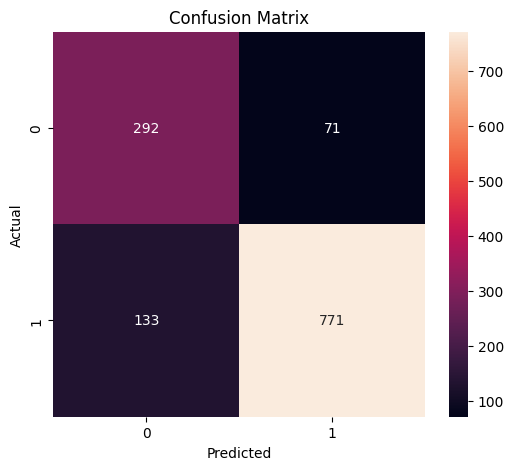


Confusion Matrix:
 [[292  71]
 [133 771]]


In [179]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print("\nConfusion Matrix:\n", cm)

### FEATURE IMPORTANCE

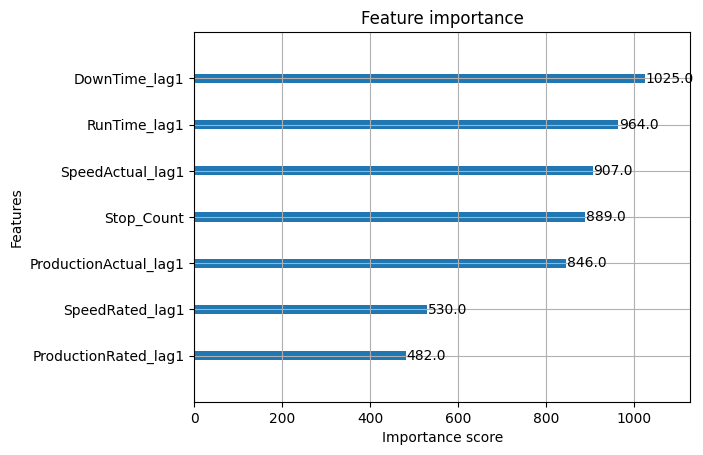

In [180]:
xgb.plot_importance(model)
plt.show()

In [181]:
print(df[['Date', 'MachineName', 'OEE', 'OEE_lag1', 'Target']].head(10))

           Date    MachineName  OEE  OEE_lag1  Target
25   2025-01-31  120 MM Ext U3  0.0       0.0     0.0
50   2025-02-01  120 MM Ext U3  0.0       0.0     0.0
52   2025-02-01  120 MM Ext U3  0.0       0.0     0.0
78   2025-02-02  120 MM Ext U3  0.0       0.0     0.0
79   2025-02-02  120 MM Ext U3  0.0       0.0     0.0
106  2025-02-03  120 MM Ext U3  0.0       0.0     0.0
111  2025-02-03  120 MM Ext U3  0.0       0.0     0.0
136  2025-02-04  120 MM Ext U3  0.0       0.0     0.0
139  2025-02-04  120 MM Ext U3  0.0       0.0     0.0
165  2025-02-05  120 MM Ext U3  0.0       0.0     0.0


## Model Training

In [182]:
# Model setup
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

model = xgb.XGBClassifier(
    objective='binary:logistic',
    max_depth=5,
    learning_rate=0.05,
    n_estimators=300,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [183]:
# Predict probability of next day degradation
y_prob = model.predict_proba(X_test)[:, 1]

# Convert to binary (threshold)
threshold = 0.6
y_pred = (y_prob > threshold).astype(int)

In [184]:
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Classification Report:

              precision    recall  f1-score   support

         0.0       0.69      0.80      0.74       363
         1.0       0.92      0.85      0.88       904

    accuracy                           0.84      1267
   macro avg       0.80      0.83      0.81      1267
weighted avg       0.85      0.84      0.84      1267

Confusion Matrix:
 [[292  71]
 [133 771]]


In [185]:
alert_df = X_test.copy()
alert_df['Degrade_Prob'] = y_prob
alert_df['Predicted'] = y_pred
alert_df['Actual'] = y_test.values
alert_df.sort_values('Degrade_Prob', ascending=False).head(10)

,RunTime_lag1,DownTime_lag1,SpeedActual_lag1,SpeedRated_lag1,ProductionActual_lag1,ProductionRated_lag1,Stop_Count,Degrade_Prob,Predicted,Actual
5745,11855.0,26066.0,17.81,28.74,5668.0,5702.21,151.0,0.994497,1,1.0
5981,24292.0,62049.0,16.89,28.74,10837.0,11681.86,143.0,0.994359,1,1.0
5746,9309.0,25311.0,15.56,30.34,2821.0,4721.16,210.0,0.993985,1,1.0
6276,22839.0,63501.0,17.22,29.46,10444.0,11227.83,238.0,0.993850,1,1.0
5468,12554.0,12587.0,37.00,0.00,7957.4,0.00,72.0,0.993572,1,1.0
6091,23755.0,62586.0,15.83,29.94,9836.0,11461.99,198.0,0.993058,1,1.0
6186,26524.0,59816.0,14.94,28.97,10737.0,12882.79,176.0,0.992351,1,1.0
6042,5283.0,4318.0,56.66,0.00,5245.3,0.00,64.0,0.992266,1,1.0
5615,1226.0,3454.0,49.41,0.00,1046.4,0.00,59.0,0.991999,1,1.0
5592,1355.0,1525.0,37.18,0.00,883.4,0.00,59.0,0.991836,1,1.0


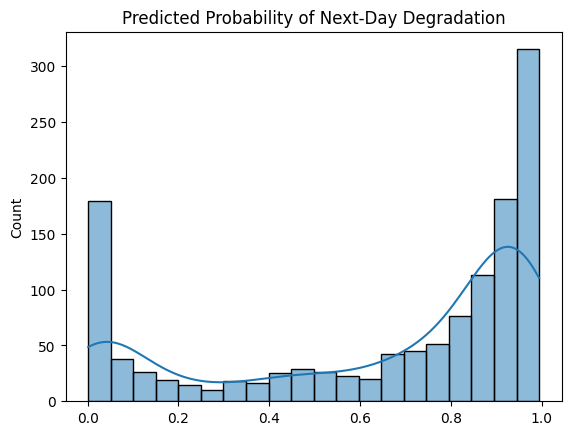

In [186]:
sns.histplot(y_prob, bins=20, kde=True)
plt.title("Predicted Probability of Next-Day Degradation")
plt.show()

In [187]:
# df.corr()

In [188]:
# oee_daily = oee_daily.drop(['DivisionName', 'ProcessName', 'WeightActual', 'WeightRated'], axis=1)
# downtime_info = downtime_info.drop(['DivisionName', 'ProcessName'], axis=1)

### Dumping Model

In [189]:
joblib.dump(model, "machineageing.pkl")

print("Model saved successfully")

Model saved successfully
